<div class="alert alert-block alert-success">
    <h1 align="center">Mall Customers Clustering Project</h1>
</div>

## Importing the libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

## Load and Prepare Data

In [63]:
data = pd.read_csv('dataset/Mall_Customers.csv')
data.drop('CustomerID', axis=1, inplace=True)
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


## EDA - Strorytelling - Visualization

In [64]:
data.Gender.value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [65]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 6.4 KB


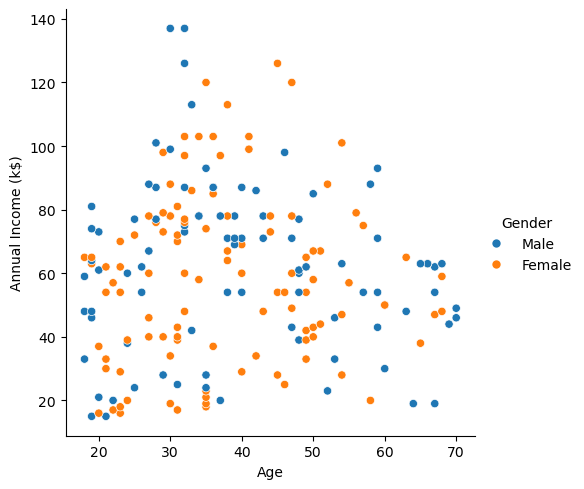

In [66]:
sns.relplot(data=data, x='Age', y='Annual Income (k$)', hue='Gender')

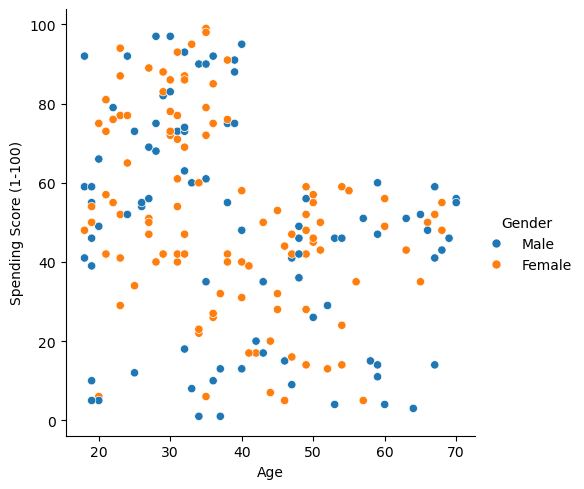

In [67]:
sns.relplot(data=data, x='Age', y='Spending Score (1-100)', hue='Gender')

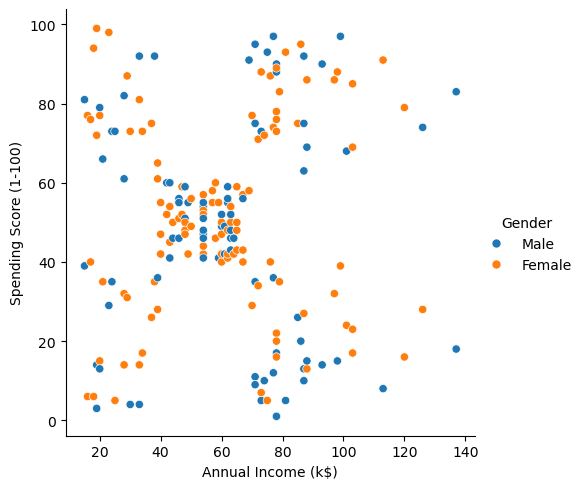

In [68]:
sns.relplot(data=data, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')

طبق شواهد کلاستر ها پنج تا هستن و از لحاظ منتقی هم درست هست.

سه سناریو در نظر میگیرم تا هر سه را امتحان کنم و سپس از بین انها بهترین خوشه بندی را انتخاب کنم.
آ : ویژگی های درآمد و امتیاز خرج
ب : ویژگی های آ بعلاوه سن
پ : همه ویژگی ها

## Data Preprocessing

In [69]:
df = data.copy()

In [70]:
preprocessor = ColumnTransformer(
    transformers= [
        ('cat', OneHotEncoder(drop='first'), ['Gender']),
        ('num', StandardScaler(), ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
    ]
)

In [71]:
preprocessed = preprocessor.fit_transform(df)


In [72]:
a = preprocessed[:, 2:].copy()
b = preprocessed[:, 1:].copy()
c = preprocessed[:, :].copy()

## Trani the Model (Clustering)

### K-means

In [73]:
labels_a = KMeans(n_clusters=5, random_state=0, init="k-means++").fit_predict(a)
labels_b = KMeans(n_clusters=5, random_state=0, init="k-means++").fit_predict(b)
labels_c = KMeans(n_clusters=5, random_state=0, init="k-means++").fit_predict(c)

c:\Users\Island\anaconda3\envs\ML_common_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Island\anaconda3\envs\ML_common_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Island\anaconda3\envs\ML_common_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [74]:
score_a = silhouette_score(a, labels_a)
score_b = silhouette_score(b, labels_b)
score_c = silhouette_score(c, labels_c)
print(score_a)
print(score_b)
print(score_c)

0.5546571631111091
0.41664341513732767
0.31015860317762334


مدلی که شامل ویژگی های درآمد و امتیاز خرج میشد بهترین نتیجه رو داد.

در ادامه بررسی میکنیم که آیا پنج کلاستر بهترین گزینه هست یا نه

In [75]:
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=0, init='k-means++').fit(a)
    wcss.append(model.inertia_)

c:\Users\Island\anaconda3\envs\ML_common_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Island\anaconda3\envs\ML_common_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Island\anaconda3\envs\ML_common_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Island\anaconda3\envs\ML_common_env\Lib\site-packages\sklearn\clust

<Axes: >

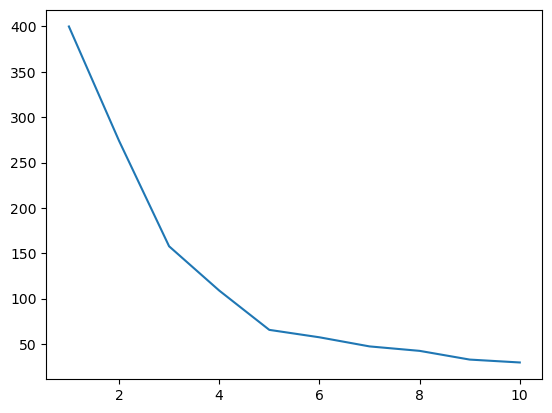

In [76]:
k_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
sns.lineplot(x=k_list, y=wcss)

با توجه به متود "البو" بیهنه ترین حالت همون پنج کلاستر هست.

In [80]:
labels = pd.DataFrame(labels_a, columns=['label'])
labeled_df = pd.concat([data[['Annual Income (k$)', 'Spending Score (1-100)']], labels], axis=1)
labeled_df

,Annual Income (k$),Spending Score (1-100),label
0,15,39,3
1,15,81,4
2,16,6,3
3,16,77,4
4,17,40,3
...,...,...,...
195,120,79,1
196,126,28,2
197,126,74,1
198,137,18,2


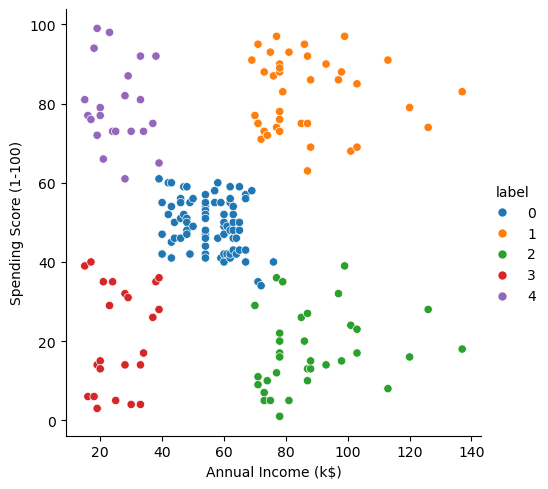

In [82]:
sns.relplot(data=labeled_df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='label', palette='tab10')

## Send us the Result (Maktabkhoone)